In [13]:
from multicam_recorder import MultiCameraRecorder
from video_synchronizer import VideoSynchronizer
import time

In [14]:
# 1. Setup recorder
recorder = MultiCameraRecorder(
    camera_ids=[0, 1],  # Your cameras
    fps=30
)


INFO:multicam_recorder:MultiCameraRecorder initialized with cameras: [0, 1]


In [15]:
# 2. Connect to cameras (once)
recorder.connect_cameras()

INFO:multicam_recorder:Connecting to camera 0...
INFO:multicam_recorder:Camera 0 connected: 1280x720 @ 30fps
INFO:multicam_recorder:Connecting to camera 1...
INFO:multicam_recorder:Camera 1 connected: 1280x720 @ 30fps
INFO:multicam_recorder:Connected to 2/2 cameras


{0: True, 1: True}

In [4]:
recorder.preview_cameras(duration=5.0)

INFO:multicam_recorder:Showing preview for 5.0s...


In [16]:
# 3. Record Trial 1
recorder.start_recording("trial_test7")
time.sleep(100)  # Record for 10 seconds
recorder.stop_recording()

INFO:multicam_recorder:Starting recording: trial_test7
INFO:multicam_recorder:Camera 0 recording to recordings/trial_test7/raw_videos/camera_0.avi
INFO:multicam_recorder:Camera 1 recording to recordings/trial_test7/raw_videos/camera_1.avi
INFO:multicam_recorder:Recording started on 2 cameras
INFO:multicam_recorder:Stopping recording...
INFO:multicam_recorder:Camera 0 stopped recording: 2739 frames
INFO:multicam_recorder:Camera 1 stopped recording: 3000 frames
INFO:multicam_recorder:Recording stopped: trial_test7


{0: (2739,
  [1770288913.904382,
   1770288913.936804,
   1770288913.968998,
   1770288914.0687308,
   1770288914.100985,
   1770288914.134311,
   1770288914.1698291,
   1770288914.2004302,
   1770288914.233574,
   1770288914.266134,
   1770288914.299389,
   1770288914.397346,
   1770288914.4307761,
   1770288914.463521,
   1770288914.496864,
   1770288914.5293062,
   1770288914.5625741,
   1770288914.594838,
   1770288914.628356,
   1770288914.726909,
   1770288914.760513,
   1770288914.793278,
   1770288914.825963,
   1770288914.858978,
   1770288914.8922439,
   1770288914.959135,
   1770288915.0910919,
   1770288915.123044,
   1770288915.1560802,
   1770288915.1900811,
   1770288915.222744,
   1770288915.261555,
   1770288915.2889369,
   1770288915.322879,
   1770288915.356094,
   1770288915.388915,
   1770288915.422158,
   1770288915.454585,
   1770288915.487345,
   1770288915.521853,
   1770288915.553664,
   1770288915.5868428,
   1770288915.61896,
   1770288915.651886,
   1770288

In [17]:
# 5. Disconnect
recorder.disconnect_cameras()

INFO:multicam_recorder:Disconnecting cameras...
INFO:multicam_recorder:Stopping camera 0...
INFO:multicam_recorder:Camera 0 stopped successfully
INFO:multicam_recorder:Stopping camera 1...
INFO:multicam_recorder:Camera 1 stopped successfully
INFO:multicam_recorder:All cameras disconnected successfully


In [4]:
sync = VideoSynchronizer()
sync.synchronize_videos("./recordings/trial_test2/raw_videos",method="brightness")


INFO:video_synchronizer:FFmpeg found
INFO:video_synchronizer:Found 2 videos to synchronize
INFO:video_synchronizer:Synchronizing by brightness detection...
INFO:video_synchronizer:Detecting flash in camera_0.mp4...
ERROR:video_synchronizer:  No flash detected in camera_0.mp4


{}

In [7]:
from pathlib import Path
import re
import numpy as np
import cv2

def _fit_time_model(ts: np.ndarray):
    """
    Fit t = a + b*i to per-frame timestamps ts (seconds since epoch).
    Returns (a, b, residuals, pred_ts)
    """
    ts = np.asarray(ts).astype(float).ravel()
    n = len(ts)
    i = np.arange(n, dtype=float)
    A = np.column_stack([np.ones(n), i])
    (a, b), *_ = np.linalg.lstsq(A, ts, rcond=None)
    pred = a + b * i
    resid = ts - pred
    return a, b, resid, pred

def _video_info(video_path: Path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        raise RuntimeError(f"Could not open video: {video_path}")
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) else float("nan")
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    return n, fps, (w, h)

def _open_writer(out_path: Path, fps: float, frame_size):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_path), fourcc, float(fps), tuple(frame_size))
    if not writer.isOpened():
        raise RuntimeError(f"Could not open VideoWriter for: {out_path}")
    return writer

def _read_frame_at(cap: cv2.VideoCapture, frame_idx: int):
    # Random access using CAP_PROP_POS_FRAMES (works best for intra-coded / some mp4s; may be slower on long GOP)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    if not ok:
        return None
    return frame

def synchronise_trial_to_cam0_and_write_videos(
    trial_folder,
    cam0_id=0,
    raw_videos_subdir="raw_videos",
    out_subdir="synchronized_videos",
    video_ext=".mp4",
    indices_out_name="sync_indices_to_cam0.npz",
    write_suffix="_synchronized.mp4",
):
    """
    1) Find camera_*_timestamps.npy in trial_folder
    2) Find videos in trial_folder/raw_videos
    3) Build timestamp-based mapping to cam0 (linear model per cam)
    4) Choose largest contiguous cam0 range where all cams have valid mapped indices
    5) Write synchronized videos (same number of frames) to trial_folder/out_subdir

    Output:
      - synchronized videos: camera_<id>_synchronized.mp4
      - index maps: sync_indices_to_cam0.npz
      - returns results dict (metrics + index maps)
    """
    trial_folder = Path(trial_folder)
    raw_dir = trial_folder / raw_videos_subdir
    if not raw_dir.exists():
        raise FileNotFoundError(f"raw_videos folder not found: {raw_dir}")

    # --- timestamps ---
    ts_files = list(trial_folder.glob("camera_*_timestamps.npy"))
    if not ts_files:
        raise FileNotFoundError(f"No timestamp .npy files found in: {trial_folder}")

    cam_re = re.compile(r"camera_(\d+)_timestamps\.npy$")
    ts_by_cam = {}
    for f in ts_files:
        m = cam_re.search(f.name)
        if m:
            cam_id = int(m.group(1))
            ts_by_cam[cam_id] = np.load(f)

    if cam0_id not in ts_by_cam:
        raise FileNotFoundError(f"Missing timestamps for cam0_id={cam0_id}. Found: {sorted(ts_by_cam.keys())}")

    # --- videos ---
    vid_by_cam = {}
    for cam_id in ts_by_cam.keys():
        vpath = raw_dir / f"camera_{cam_id}{video_ext}"
        if vpath.exists():
            vid_by_cam[cam_id] = vpath
        else:
            candidates = list(raw_dir.glob(f"camera_{cam_id}.*"))
            if candidates:
                vid_by_cam[cam_id] = candidates[0]

    if cam0_id not in vid_by_cam:
        raise FileNotFoundError(f"Missing video for cam0_id={cam0_id} in {raw_dir}")

    cams = sorted(ts_by_cam.keys())

    # --- per-camera models + checks ---
    per_cam = {}
    for cam_id in cams:
        ts = np.asarray(ts_by_cam[cam_id]).astype(float).ravel()
        if len(ts) < 5:
            raise ValueError(f"Too few timestamps for camera {cam_id}: {len(ts)}")

        a, b, resid, pred = _fit_time_model(ts)
        est_fps = 1.0 / b if b != 0 else float("inf")

        if cam_id in vid_by_cam:
            nframes_v, fps_v, (w, h) = _video_info(vid_by_cam[cam_id])
            vinfo = {
                "path": str(vid_by_cam[cam_id]),
                "frame_count_cv2": nframes_v,
                "fps_cv2": fps_v,
                "resolution": (w, h),
            }
        else:
            vinfo = {"path": None, "frame_count_cv2": None, "fps_cv2": None, "resolution": None}

        per_cam[cam_id] = {
            "n_timestamps": int(len(ts)),
            "timestamp_start": float(ts[0]),
            "timestamp_end": float(ts[-1]),
            "duration_timestamps_s": float(ts[-1] - ts[0]),
            "time_model": {"a": float(a), "b_sec_per_frame": float(b), "est_fps_from_ts": float(est_fps)},
            "fit_residuals": {
                "rms_s": float(np.sqrt(np.mean(resid**2))),
                "p95_abs_s": float(np.percentile(np.abs(resid), 95)),
                "max_abs_s": float(np.max(np.abs(resid))),
            },
            "video": vinfo,
            "checks": {
                "video_minus_timestamps_frames": (
                    None if vinfo["frame_count_cv2"] is None else int(vinfo["frame_count_cv2"] - len(ts))
                )
            },
        }

    # --- mapping to cam0 ---
    a0 = per_cam[cam0_id]["time_model"]["a"]
    b0 = per_cam[cam0_id]["time_model"]["b_sec_per_frame"]
    n0 = per_cam[cam0_id]["n_timestamps"]

    i0 = np.arange(n0, dtype=float)
    t0_ref = a0 + b0 * i0  # smooth reference times

    index_map = {cam0_id: np.arange(n0, dtype=np.int64)}
    valid_all = np.ones(n0, dtype=bool)

    for cam_id in cams:
        if cam_id == cam0_id:
            continue

        ak = per_cam[cam_id]["time_model"]["a"]
        bk = per_cam[cam_id]["time_model"]["b_sec_per_frame"]
        nk = per_cam[cam_id]["n_timestamps"]

        j = np.rint((t0_ref - ak) / bk).astype(np.int64)
        valid = (j >= 0) & (j < nk)
        valid_all &= valid
        index_map[cam_id] = j

        # metrics
        start_offset_s = (ak - a0)
        drift_ratio = (bk / b0) if b0 != 0 else np.nan
        drift_ppm = (drift_ratio - 1.0) * 1e6 if np.isfinite(drift_ratio) else np.nan

        t_k_mapped = ak + bk * j.astype(float)
        timing_err = t_k_mapped - t0_ref
        timing_err_valid = timing_err[valid]

        per_cam[cam_id]["sync_to_cam0"] = {
            "start_offset_s_model": float(start_offset_s),
            "drift_ratio_sec_per_frame": float(drift_ratio),
            "drift_ppm": float(drift_ppm),
            "overlap_valid_fraction": float(np.mean(valid)),
            "timing_error_valid": {
                "rms_s": float(np.sqrt(np.mean(timing_err_valid**2))) if timing_err_valid.size else np.nan,
                "p95_abs_s": float(np.percentile(np.abs(timing_err_valid), 95)) if timing_err_valid.size else np.nan,
                "max_abs_s": float(np.max(np.abs(timing_err_valid))) if timing_err_valid.size else np.nan,
                "mean_s": float(np.mean(timing_err_valid)) if timing_err_valid.size else np.nan,
            },
        }

    # --- largest contiguous overlap on cam0 axis ---
    if not np.any(valid_all):
        raise RuntimeError("No overlapping frames found across all cameras when syncing to cam0.")

    idx = np.where(valid_all)[0]
    breaks = np.where(np.diff(idx) > 1)[0]
    blocks = np.split(idx, breaks + 1)
    best_block = max(blocks, key=len)
    start0 = int(best_block[0])
    end0 = int(best_block[-1])
    aligned_n = int(end0 - start0 + 1)

    # trim maps
    for cam_id in list(index_map.keys()):
        index_map[cam_id] = index_map[cam_id][start0 : end0 + 1].astype(np.int64)

    # --- monotonicity check ---
    monotonicity = {}
    for cam_id, j in index_map.items():
        diffs = np.diff(j)
        monotonicity[cam_id] = {
            "nondecreasing_fraction": float(np.mean(diffs >= 0)) if len(diffs) else 1.0,
            "strictly_increasing_fraction": float(np.mean(diffs > 0)) if len(diffs) else 1.0,
            "min_step": int(diffs.min()) if len(diffs) else 0,
            "max_step": int(diffs.max()) if len(diffs) else 0,
        }

    # --- decide output fps + frame size from cam0 video (prefer actual video fps if valid) ---
    cam0_video_path = Path(per_cam[cam0_id]["video"]["path"])
    _, fps0_cv2, (w0, h0) = _video_info(cam0_video_path)
    fps_out = fps0_cv2 if np.isfinite(fps0_cv2) and fps0_cv2 > 0 else (1.0 / b0 if b0 > 0 else 30.0)
    frame_size_out = (w0, h0)

    # --- write synchronized videos ---
    out_dir = trial_folder / out_subdir
    out_dir.mkdir(parents=True, exist_ok=True)

    # open captures
    caps = {}
    for cam_id in cams:
        if cam_id not in vid_by_cam:
            raise FileNotFoundError(f"Missing video for camera {cam_id} (needed to write synchronized video).")
        cap = cv2.VideoCapture(str(vid_by_cam[cam_id]))
        if not cap.isOpened():
            cap.release()
            raise RuntimeError(f"Could not open video for camera {cam_id}: {vid_by_cam[cam_id]}")
        caps[cam_id] = cap

    writers = {}
    try:
        # writers: keep each camera's native frame size if you want; but you asked "all same number of frames".
        # We'll also enforce same frame size by resizing to cam0 frame size for consistency.
        for cam_id in cams:
            out_path = out_dir / f"camera_{cam_id}{write_suffix}"
            writers[cam_id] = _open_writer(out_path, fps_out, frame_size_out)

        # write frame-by-frame in aligned range
        for t in range(aligned_n):
            for cam_id in cams:
                src_idx = int(index_map[cam_id][t])
                frame = _read_frame_at(caps[cam_id], src_idx)
                if frame is None:
                    raise RuntimeError(f"Failed to read frame {src_idx} from camera {cam_id} video.")
                # resize to cam0 size for consistent outputs
                if (frame.shape[1], frame.shape[0]) != frame_size_out:
                    frame = cv2.resize(frame, frame_size_out, interpolation=cv2.INTER_LINEAR)
                writers[cam_id].write(frame)

        # flush/release
        for w in writers.values():
            w.release()
        writers.clear()

    finally:
        # release caps even on error
        for cap in caps.values():
            cap.release()
        # ensure writers released on error
        for w in writers.values():
            w.release()

    # --- save index maps ---
    npz_path = trial_folder / indices_out_name
    np.savez_compressed(
        npz_path,
        cam0_id=np.int64(cam0_id),
        cam_ids=np.array(sorted(index_map.keys()), dtype=np.int64),
        start0=np.int64(start0),
        end0=np.int64(end0),
        fps_out=float(fps_out),
        frame_size_out=np.array(frame_size_out, dtype=np.int64),
        **{f"cam_{cid}": idxs for cid, idxs in index_map.items()},
    )

    results = {
        "trial_folder": str(trial_folder),
        "raw_videos_folder": str(raw_dir),
        "out_folder": str(out_dir),
        "cam0_id": cam0_id,
        "fps_out": float(fps_out),
        "frame_size_out": frame_size_out,
        "cameras": per_cam,
        "common": {
            "cam0_common_range_inclusive": (start0, end0),
            "aligned_frame_count": aligned_n,
            "aligned_duration_s_from_cam0_model": float((end0 - start0) * b0),
        },
        "monotonicity": monotonicity,
        "index_map": index_map,
        "index_map_file": str(npz_path),
        "written_videos": {cam_id: str(out_dir / f"camera_{cam_id}{write_suffix}") for cam_id in cams},
    }

    # --- print summary ---
    print(f"\n=== Sync + write summary (to cam {cam0_id}) ===")
    print(f"Trial folder: {trial_folder}")
    print(f"Raw videos:   {raw_dir}")
    print(f"Output dir:   {out_dir}")
    print(f"Found cams:   {cams}")
    print(f"Common cam0 range: [{start0}, {end0}] -> aligned frames: {aligned_n}")
    print(f"Output fps: {fps_out:.3f}, output size: {frame_size_out[0]}x{frame_size_out[1]}")
    print(f"Saved index maps: {npz_path}")
    print("")
    for cam_id in cams:
        n_ts = per_cam[cam_id]["n_timestamps"]
        vfc = per_cam[cam_id]["video"]["frame_count_cv2"]
        dm = per_cam[cam_id]["checks"]["video_minus_timestamps_frames"]
        est_fps = per_cam[cam_id]["time_model"]["est_fps_from_ts"]
        print(f"Cam {cam_id}: n_ts={n_ts}, est_fps(ts)={est_fps:.3f}, video_frames={vfc}, video-ts={dm}")
        if cam_id != cam0_id:
            s = per_cam[cam_id].get("sync_to_cam0", {})
            te = s.get("timing_error_valid", {})
            print(f"  start_offset(model)={s.get('start_offset_s_model', np.nan):+.4f}s, drift={s.get('drift_ppm', np.nan):+.1f} ppm")
            print(f"  timing_err rms={te.get('rms_s', np.nan):.4f}s, p95={te.get('p95_abs_s', np.nan):.4f}s, max={te.get('max_abs_s', np.nan):.4f}s")
        print(f"  monotonic nondecreasing={monotonicity[cam_id]['nondecreasing_fraction']:.3f}, max_step={monotonicity[cam_id]['max_step']}")
        print(f"  wrote: {results['written_videos'][cam_id]}")
    print("")

    return results


# ----------------------------
# Example usage (paste into a notebook cell)
# ----------------------------
# trial_dir = r"./recordings/2026-02-04_12-00-00"  # <- change this
# results = synchronise_trial_to_cam0_and_write_videos(trial_dir, cam0_id=0)
# results["common"]


In [1]:
from sync_by_timestamps import synchronize_videos_to_ideal_fps
from plot_sync_results import plot_sync_results, plot_sync_summary_stats


In [2]:
# Synchronize all videos to camera 0
trial_dir = r"./recordings/trial_test7"  # <- change this

# Synchronize to ideal 30 FPS (or whatever you specify)
results = synchronize_videos_to_ideal_fps(
    trial_folder=trial_dir,
    target_fps=30.0,  # Your target FPS
    max_time_diff_ms=50.0
)


Timestamp-based Synchronization to Ideal 30.0 FPS Clock
Trial folder: recordings/trial_test7
Raw videos:   recordings/trial_test7/raw_videos
Output dir:   recordings/trial_test7/synchronized_videos
Target FPS:   30.0

[1] Loading timestamps...
  Camera 1: 3000 timestamps, range: [1770288913.908, 1770289013.989]s
  Camera 0: 2739 timestamps, range: [1770288913.904, 1770289013.894]s

[2] Finding global time range...
  Global start time: 1770288913.908s
  Global end time:   1770289013.894s
  Duration:          99.986s

[3] Creating ideal 30.0 FPS timing grid...
  Ideal frame count: 3000
  Ideal duration:    99.967s

[4] Finding video files...
  Camera 0: camera_0.avi
  Camera 1: camera_1.avi

[5] Getting video properties...
  Output FPS:        30.00
  Output resolution: 1280x720 (from camera 0)
  Output frames:     3000

[6] Building frame mappings to ideal clock...
  Camera 0:
    Mean time diff: 10.70 ms
    Max time diff:  64.00 ms
    RMS time diff:  14.15 ms
    P95 time diff:  31.


📊 Plots saved to: recordings/trial_test7/synchronization_plots/sync_analysis.png
📊 PDF saved to: recordings/trial_test7/synchronization_plots/sync_analysis.pdf


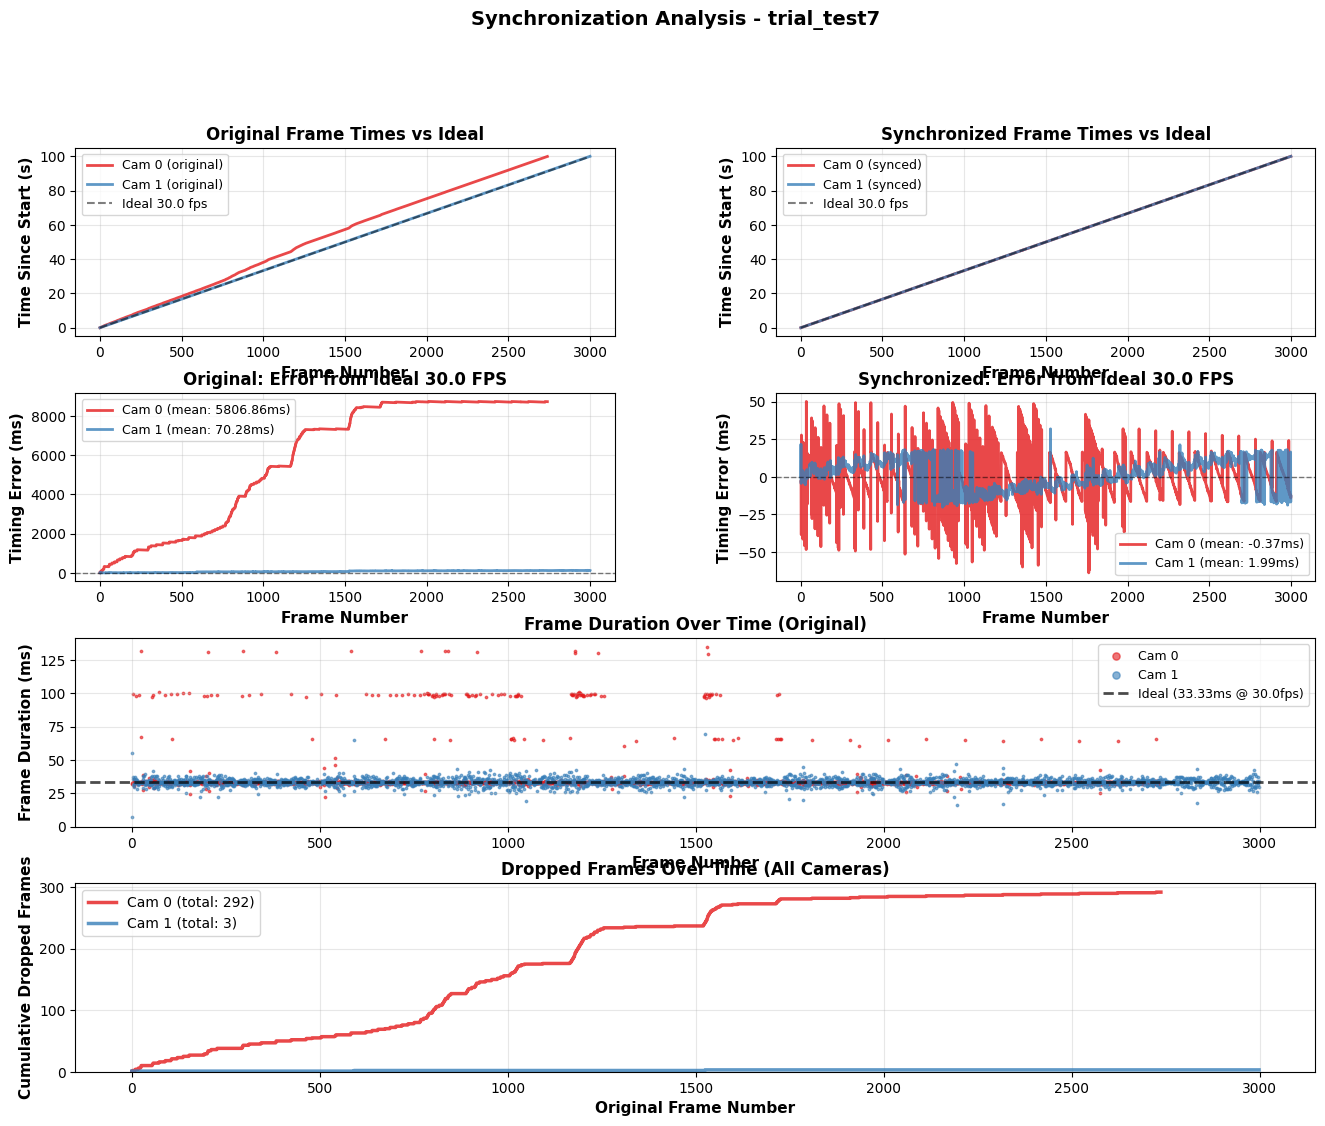

📊 Summary plots saved to: recordings/trial_test7/synchronization_plots/sync_summary.png


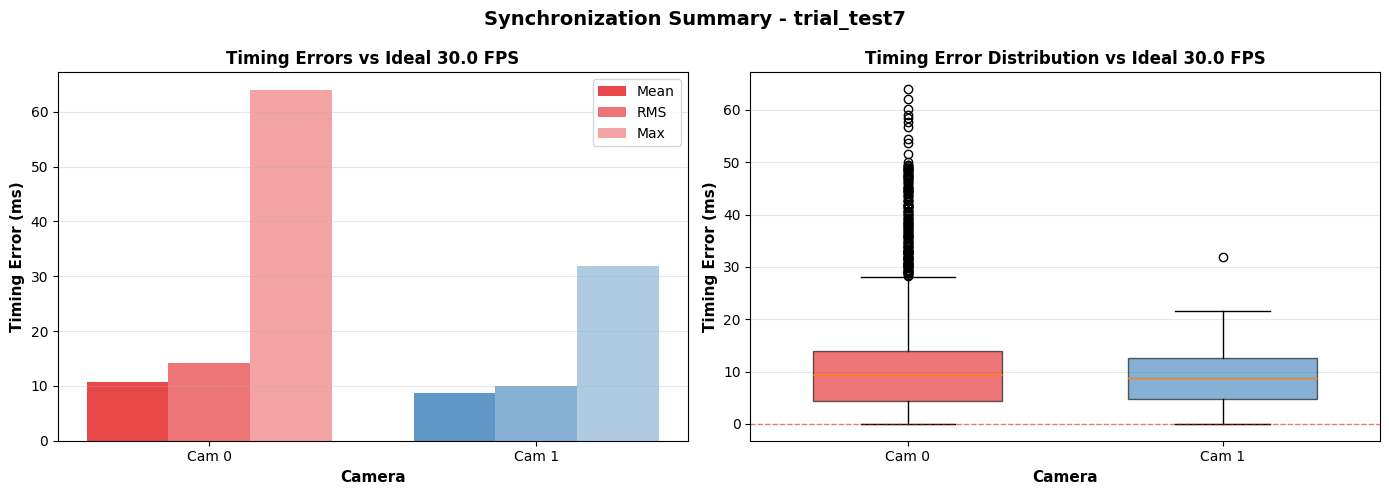

In [8]:
# Create plots
figs = plot_sync_results(
    results=results,
    trial_folder=trial_dir,
    save_plots=True,
    show_plots=True
)

# Summary stats
fig_summary = plot_sync_summary_stats(
    results=results,
    trial_folder=trial_dir,
    save_plots=True
)

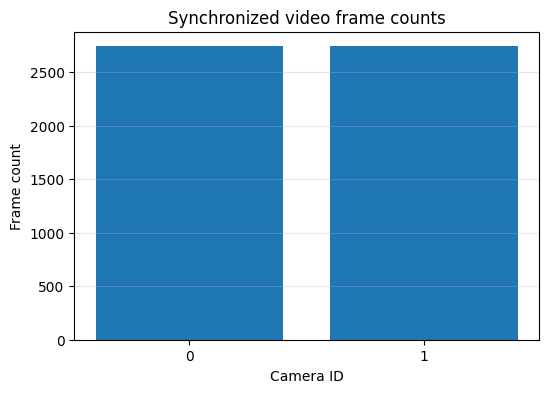

{0: 2739, 1: 2739}

In [26]:
trial_dir = r"./recordings/trial_test7"  # <- change this
frame_counts = plot_synced_video_frame_counts(trial_dir)
frame_counts


In [4]:
from pathlib import Path
import cv2
import numpy as np

def save_synced_videos_side_by_side(
    trial_folder,
    synced_subdir="synchronized_videos",
    out_name="synchronized_side_by_side.avi",
    max_width=1920,
):
    """
    Combine synchronized videos into a single side-by-side MP4 for offline review.

    Assumes:
      - Videos are already synchronized
      - All have identical frame counts
      - Filenames: camera_<id>_synchronized.mp4
    """
    trial_folder = Path(trial_folder)
    synced_dir = trial_folder / synced_subdir
    out_path = trial_folder / out_name

    videos = sorted(synced_dir.glob("camera_*_synchronized.avi"))
    if not videos:
        raise FileNotFoundError(f"No synchronized videos found in {synced_dir}")

    caps = []
    cam_ids = []

    for v in videos:
        cap = cv2.VideoCapture(str(v))
        if not cap.isOpened():
            raise RuntimeError(f"Could not open {v}")
        caps.append(cap)
        cam_ids.append(int(v.stem.split("_")[1]))

    # --- checks ---
    frame_counts = [int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) for cap in caps]
    if len(set(frame_counts)) != 1:
        raise ValueError(f"Frame count mismatch: {dict(zip(cam_ids, frame_counts))}")

    fps = caps[0].get(cv2.CAP_PROP_FPS)
    n_frames = frame_counts[0]

    # Read one frame to determine sizes
    ok, first_frame = caps[0].read()
    if not ok:
        raise RuntimeError("Failed to read first frame")
    h, w = first_frame.shape[:2]

    # Reset all captures to frame 0
    for cap in caps:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    tiled_w = w * len(caps)
    tiled_h = h

    # Optional downscale to fit screen width
    scale = 1.0
    if tiled_w > max_width:
        scale = max_width / tiled_w
        tiled_w = int(tiled_w * scale)
        tiled_h = int(tiled_h * scale)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(
        str(out_path),
        fourcc,
        fps,
        (tiled_w, tiled_h),
    )
    if not writer.isOpened():
        raise RuntimeError(f"Could not open VideoWriter for {out_path}")

    print(f"Writing side-by-side video:")
    print(f"  cameras: {cam_ids}")
    print(f"  frames:  {n_frames}")
    print(f"  fps:     {fps:.2f}")
    print(f"  output:  {out_path}")

    # --- write ---
    for i in range(n_frames):
        frames = []
        for cam_id, cap in zip(cam_ids, caps):
            ok, frame = cap.read()
            if not ok:
                raise RuntimeError(f"Failed reading frame {i} from camera {cam_id}")

            # overlay text
            cv2.putText(
                frame,
                f"Cam {cam_id} | frame {i}",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                (0, 255, 0),
                2,
                cv2.LINE_AA,
            )
            frames.append(frame)

        combined = np.hstack(frames)

        if scale != 1.0:
            combined = cv2.resize(
                combined,
                (tiled_w, tiled_h),
                interpolation=cv2.INTER_AREA,
            )

        writer.write(combined)

    # cleanup
    writer.release()
    for cap in caps:
        cap.release()

    print("Done ✅")
    return out_path





In [5]:
# ---- usage ----
trial_dir = r"./recordings/trial_test7"  # <- change this

out_video = save_synced_videos_side_by_side(trial_dir)
out_video

Writing side-by-side video:
  cameras: [0, 1]
  frames:  3000
  fps:     30.00
  output:  recordings/trial_test7/synchronized_side_by_side.avi
Done ✅


PosixPath('recordings/trial_test7/synchronized_side_by_side.avi')